<center><h1>Desafio Data Science - Creditas</h1></center>
<h3>Bruno Borges de Souza</h3>

O objetivo deste desafio é construir um modelo de classificação que retorne a probabilidade de um cliente ser enviado para análise de crédito, **dado que ele foi pré-aprovado** para o empréstimo com garantia de automóvel. Com essa probabilidade a Creditas pode priorizar o atendimento dos leads com maior chance de avançar no funil.

**O que mudou nesta versão (v2) em relação à anterior**

* A população modelada passa a ser **todos** os pré-aprovados. Na versão anterior um `fillna` com `np.median` (que devolve `NaN`) fazia o filtro de outliers descartar ~10 mil linhas, justamente as de `collateral_debt` nulo, que convertem mais.
* A etapa de previsão de `pre_approved` foi removida: não é o alvo do desafio e não melhora o modelo final (verificado na seção 5.3).
* Separação treino/teste feita **antes** de qualquer análise; toda escolha de variáveis e de modelo usa apenas validação cruzada no treino. O teste é usado uma única vez.
* Nenhuma linha é removida por outlier: o modelo de árvores é invariante a transformações monotônicas e trata nulos nativamente.
* Novas variáveis: razões financeiras (LTV sobre a garantia líquida, comprometimento de renda, prazo implícito), indicadores de dado faltante, canal/landing page/dispositivo e atributos do texto do motivo do empréstimo.
* Avaliação focada em **ranking e priorização** (AUC, PR-AUC, lift, captura, calibração), com validação fora do tempo e análise de sensibilidade.

# Conteúdo

1. [Carga dos dados e funil](#1)
2. [Qualidade dos dados e variáveis descartadas](#2)
3. [Separação treino/teste e análise exploratória](#3)
4. [Engenharia de variáveis](#4)
5. [Modelagem](#5)
6. [Avaliação final na base de teste](#6)
7. [Robustez](#7)
8. [Interpretação do modelo](#8)
9. [Conclusão](#9)

In [1]:
import re
import unicodedata
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

SEED = 1234
ALVO = 'sent_to_analysis'

# 1. Carga dos dados e funil <a id="1"></a>

In [2]:
base = pd.read_csv('dataset.csv')
description = pd.read_csv('description.csv', header=None, names=['coluna', 'descricao'])
print('Linhas totalmente duplicadas removidas:', base.duplicated().sum())
base = base.drop_duplicates().reset_index(drop=True)
assert base.id.is_unique
base.info()

Linhas totalmente duplicadas removidas: 4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35017 entries, 0 to 35016
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    35017 non-null  int64  
 1   age                   35015 non-null  float64
 2   monthly_income        35015 non-null  float64
 3   collateral_value      34996 non-null  float64
 4   loan_amount           35014 non-null  float64
 5   city                  34994 non-null  object 
 6   state                 35013 non-null  object 
 7   collateral_debt       24647 non-null  float64
 8   verified_restriction  26327 non-null  float64
 9   dishonored_checks     35017 non-null  int64  
 10  expired_debts         35017 non-null  int64  
 11  banking_debts         35017 non-null  int64  
 12  commercial_debts      35017 non-null  int64  
 13  protests              35017 non-null  int64  
 14  marital_status        415 no

O funil tem três passos: lead → pré-aprovado → enviado para análise. Nenhum lead não pré-aprovado é enviado para análise, portanto a população de interesse são apenas os pré-aprovados, e é só neles que o modelo é treinado e avaliado.

In [3]:
pre = base[base.pre_approved == 1]
funil = pd.Series({
    'Leads': len(base),
    'Pré-aprovados': len(pre),
    'Pré-aprovados com ficha completa': int(pre.form_completed.sum()),
    'Enviados para análise': int(pre[ALVO].sum()),
    'Enviados para análise sem pré-aprovação': int(base.loc[base.pre_approved == 0, ALVO].sum()),
}, name='quantidade').to_frame()
funil['% dos pré-aprovados'] = (funil.quantidade / len(pre) * 100).round(1)
display(funil)

print('Taxa de envio para análise entre pré-aprovados: %.1f%%' % (pre[ALVO].mean() * 100))
pd.crosstab(pre.form_completed, pre[ALVO], margins=True)

,quantidade,% dos pré-aprovados
Leads,35017,233.5
Pré-aprovados,14998,100.0
Pré-aprovados com ficha completa,4167,27.8
Enviados para análise,3269,21.8
Enviados para análise sem pré-aprovação,0,0.0


Taxa de envio para análise entre pré-aprovados: 21.8%


sent_to_analysis,0.0,1.0,All
form_completed,,,
0.0,9063,1768,10831
1.0,2666,1501,4167
All,11729,3269,14998


A classe positiva representa cerca de 22% dos pré-aprovados. `form_completed` não é uma etapa obrigatória (há clientes enviados sem ficha completa) e também aparece preenchida em leads não pré-aprovados, o que indica que ela é registrada no site antes do atendimento. Ela é mantida como preditora, e a seção 7 mostra o desempenho do modelo sem ela, caso essa informação não esteja disponível no momento da priorização.

# 2. Qualidade dos dados e variáveis descartadas <a id="2"></a>

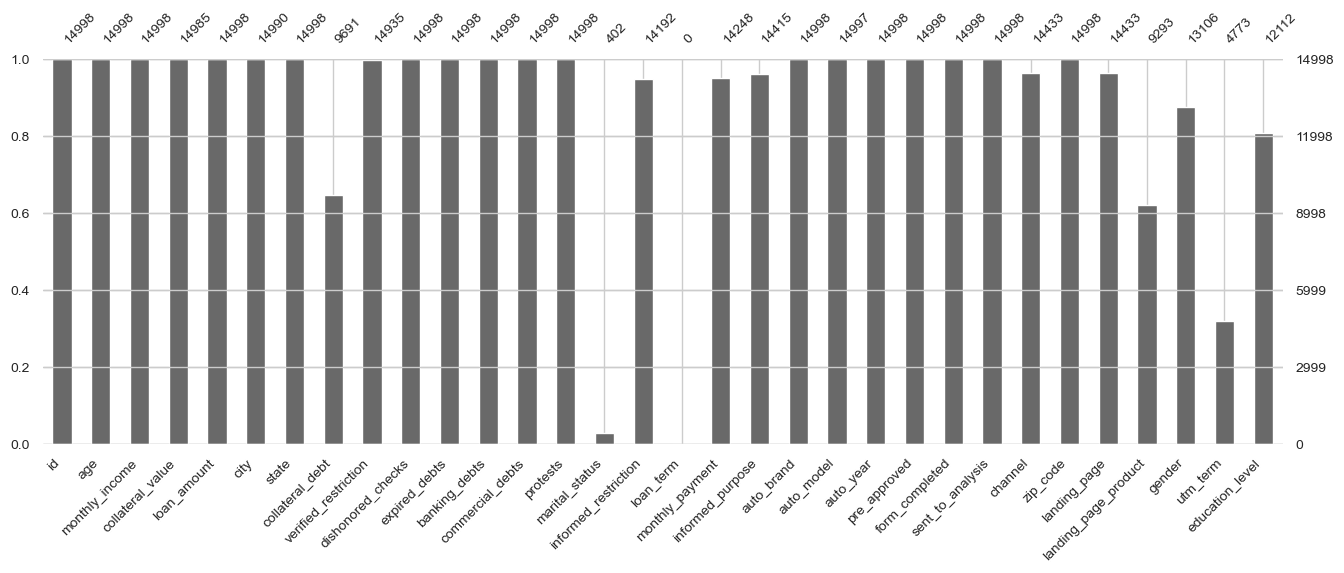

In [4]:
dados = pre.dropna(subset=[ALVO]).reset_index(drop=True)
msno.bar(dados, figsize=(16, 5), fontsize=10);

Para cada coluna com dados faltantes, a tabela abaixo compara a taxa de envio para análise quando o valor está preenchido e quando está nulo. Se o nulo fosse aleatório as duas taxas seriam parecidas.

In [5]:
linhas = []
for col in dados.columns:
    nulo = dados[col].isna()
    if nulo.any() and not nulo.all():
        linhas.append({'coluna': col, '% nulo': nulo.mean() * 100,
                       'taxa de envio (preenchido)': dados.loc[~nulo, ALVO].mean() * 100,
                       'taxa de envio (nulo)': dados.loc[nulo, ALVO].mean() * 100})
pd.DataFrame(linhas).set_index('coluna').sort_values('% nulo', ascending=False).round(1)

,% nulo,taxa de envio (preenchido),taxa de envio (nulo)
coluna,,,
marital_status,97.3,91.8,19.9
utm_term,68.2,19.6,22.8
landing_page_product,38.0,18.8,26.6
collateral_debt,35.4,19.3,26.4
education_level,19.2,21.8,21.6
gender,12.6,21.2,26.3
informed_restriction,5.4,21.8,22.3
monthly_payment,5.0,21.8,22.1
informed_purpose,3.9,21.9,19.0


Decisões tomadas a partir da tabela:

* **`marital_status`**: preenchido em menos de 3% dos casos e, quando preenchido, cerca de 90% foram enviados para análise. É um campo coletado mais adiante no funil, ou seja, **vazamento de informação**. Descartado.
* **`loan_term`**: 100% nulo. Descartado.
* **`collateral_debt`**: 35% nulo, e os nulos convertem mais. O nulo é informativo, então é mantido como nulo (o LightGBM trata nativamente) e ganha um indicador `debt_missing`. Nenhuma linha é descartada.
* **`utm_term`, `landing_page_product`, `education_level`, `gender`, `channel`**: nulo vira uma categoria própria.
* **`id`**: não é usado como preditor. A taxa de envio muda ao longo dos ids (seção 7), mas um identificador sequencial não generaliza para leads futuros.
* **`city`, `auto_model`, `landing_page`, `zip_code` completo**: cardinalidade muito alta. Foram testados em validação cruzada (como categoria e como frequência) e não trouxeram ganho; ficam de fora. Do CEP é usado apenas o primeiro dígito (região).

# 3. Separação treino/teste e análise exploratória <a id="3"></a>

A base é separada em treino (80%) e teste (20%) de forma estratificada **antes** de qualquer análise. A exploração e todas as decisões de modelagem usam somente o treino.

In [6]:
idx_treino, idx_teste = train_test_split(dados.index, test_size=0.2, stratify=dados[ALVO], random_state=SEED)
treino, teste = dados.loc[idx_treino].copy(), dados.loc[idx_teste].copy()
y_treino, y_teste = treino[ALVO].astype(int).values, teste[ALVO].astype(int).values
print('Treino: %d linhas, taxa de envio %.1f%%' % (len(treino), y_treino.mean() * 100))
print('Teste:  %d linhas, taxa de envio %.1f%%' % (len(teste), y_teste.mean() * 100))

Treino: 11998 linhas, taxa de envio 21.8%
Teste:  3000 linhas, taxa de envio 21.8%


### Taxa de envio por variável categórica

A linha tracejada é a taxa média do treino. Categorias com menos de 100 clientes foram omitidas.

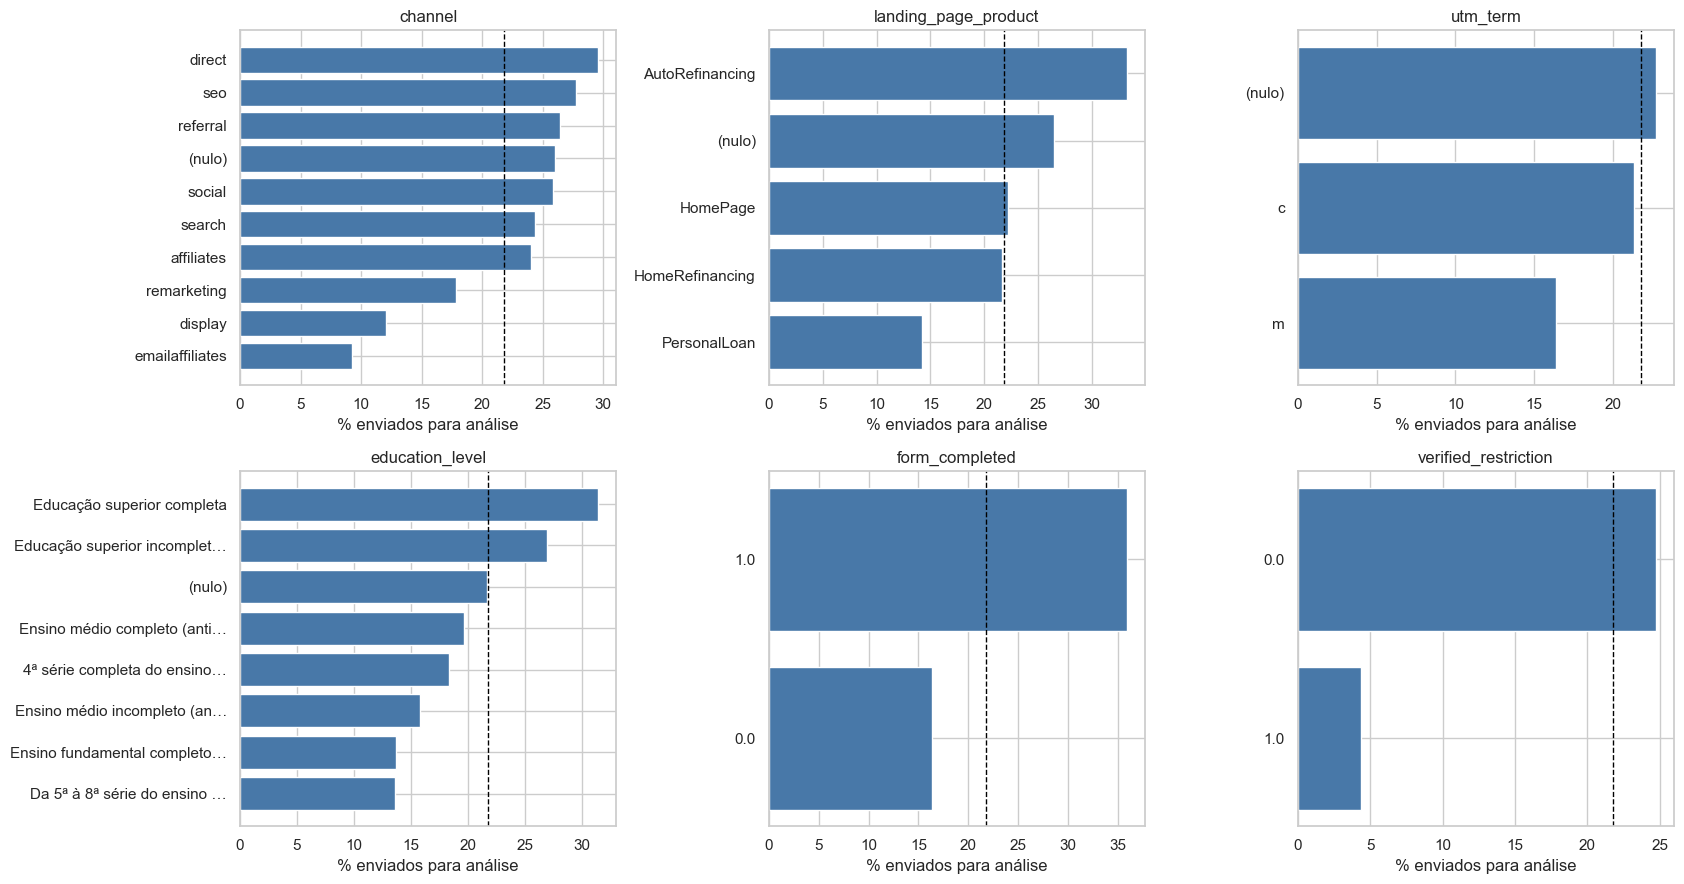

In [7]:
def taxa_por_categoria(df, col, ax, min_n=100):
    g = df.groupby(df[col].fillna('(nulo)').astype(str))[ALVO].agg(['mean', 'size'])
    g = g[g['size'] >= min_n].sort_values('mean')
    rotulos = [r if len(r) <= 28 else r[:27] + '…' for r in g.index]
    ax.barh(rotulos, g['mean'] * 100, color='#4878a8')
    ax.axvline(df[ALVO].mean() * 100, color='black', ls='--', lw=1)
    ax.set_title(col); ax.set_xlabel('% enviados para análise')

categoricas_eda = ['channel', 'landing_page_product', 'utm_term', 'education_level', 'form_completed', 'verified_restriction']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for col, ax in zip(categoricas_eda, axes.ravel()):
    taxa_por_categoria(treino, col, ax)
plt.tight_layout()

### Taxa de envio por faixa das variáveis numéricas

Cada ponto é um decil da variável no treino.

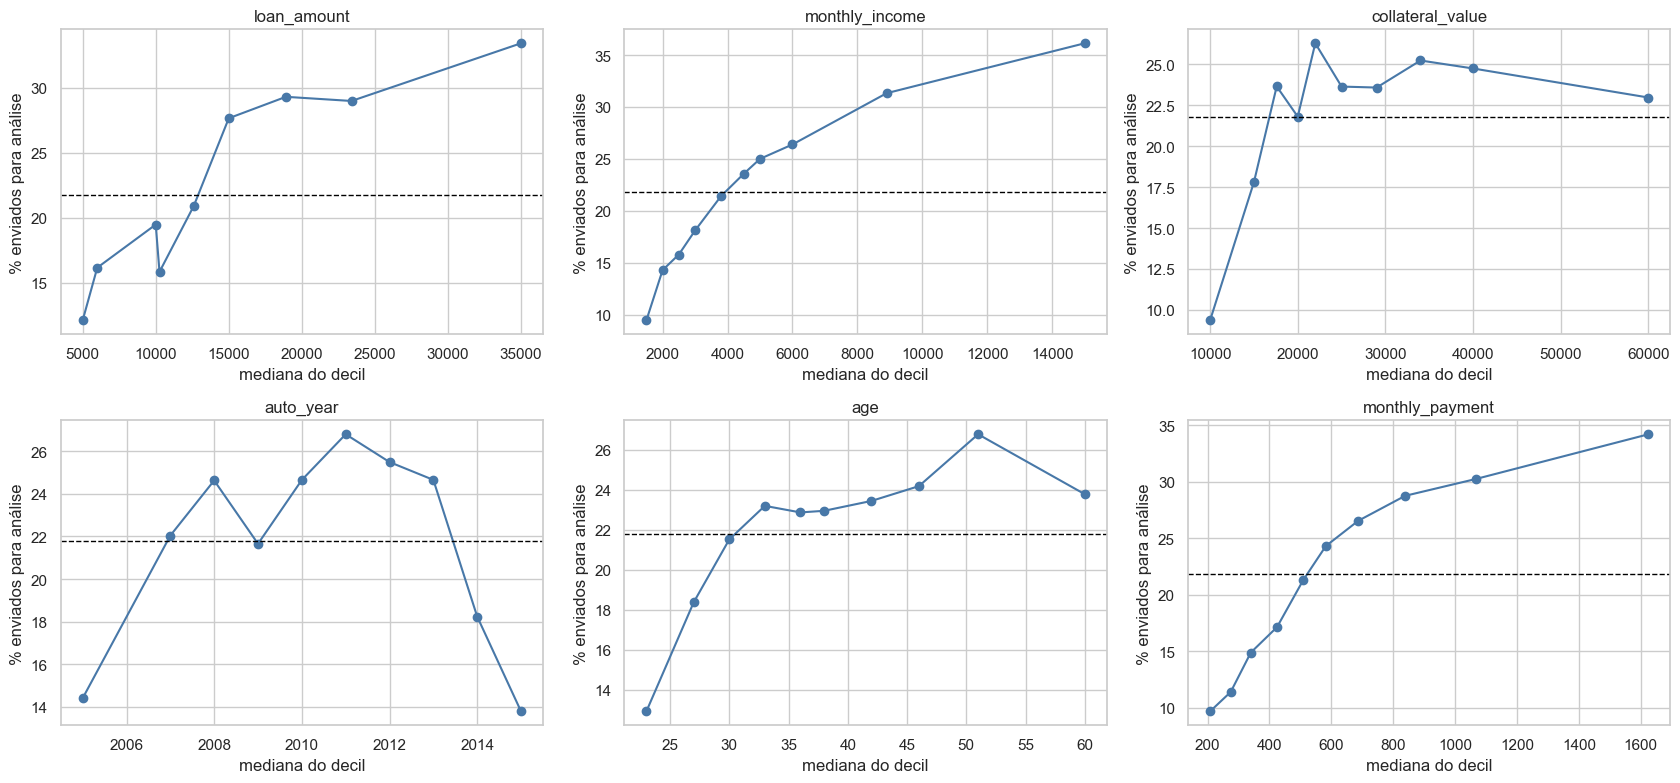

In [8]:
numericas_eda = ['loan_amount', 'monthly_income', 'collateral_value', 'auto_year', 'age', 'monthly_payment']
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for col, ax in zip(numericas_eda, axes.ravel()):
    faixa = pd.qcut(treino[col], 10, duplicates='drop')
    g = treino.groupby(faixa, observed=True).agg(x=(col, 'median'), taxa=(ALVO, 'mean'))
    ax.plot(g.x, g.taxa * 100, marker='o', color='#4878a8')
    ax.axhline(y_treino.mean() * 100, color='black', ls='--', lw=1)
    ax.set_title(col); ax.set_xlabel('mediana do decil'); ax.set_ylabel('% enviados para análise')
plt.tight_layout()

### Valores extremos

As variáveis monetárias têm valores claramente irreais (erros de digitação). Como o lead continua existindo e precisa de um score em produção, **nenhuma linha é removida**. Para o LightGBM os extremos não são um problema, pois as árvores dependem só da ordenação dos valores. Para a regressão logística usada como referência, as variáveis numéricas passam por uma transformação por quantis ajustada apenas no treino.

In [9]:
treino[['age', 'monthly_income', 'collateral_value', 'loan_amount', 'collateral_debt', 'monthly_payment']] \
    .describe(percentiles=[.01, .5, .99]).T.round(0)

,count,mean,std,min,1%,50%,99%,max
age,11998.0,38.0,12.0,18.0,19.0,36.0,70.0,115.0
monthly_income,11998.0,10787.0,154165.0,0.0,1000.0,4000.0,26015.0,11000000.0
collateral_value,11987.0,39018.0,488303.0,0.0,6000.0,23000.0,98280.0,32000000.0
loan_amount,11998.0,14634.0,14101.0,2500.0,5000.0,10500.0,60000.0,719000.0
collateral_debt,7758.0,4528.0,114895.0,0.0,0.0,0.0,38000.0,10100000.0
monthly_payment,11407.0,891.0,20356.0,0.0,162.0,551.0,2753.0,2163889.0


# 4. Engenharia de variáveis <a id="4"></a>

A função abaixo cria todas as variáveis. Ela usa apenas informações da própria linha (não aprende nada da base), portanto pode ser aplicada a treino, teste ou a um lead novo sem risco de vazamento.

* **Razões financeiras**: `ltv_gross` (empréstimo / valor do carro), `ltv_net` (empréstimo / valor do carro líquido da dívida), `debt_ratio`, `pti` (parcela / renda), `loan_income`, `value_income` e `implied_term` (empréstimo / parcela, uma aproximação do prazo, já que `loan_term` está vazio).
* **Dados faltantes**: `debt_missing` e `n_missing` (quantos campos opcionais o cliente deixou em branco).
* **Restrições**: `n_restr`, soma dos indicadores de restrição.
* **Texto do motivo do empréstimo**: tamanho, número de palavras, proporção de maiúsculas, presença de dígitos e pontuação, e grupos de palavras-chave (dívidas, investimento, reforma, pessoal, veículo).
* **Marketing e perfil**: canal, produto da landing page, dispositivo, estado, marca do carro, escolaridade, gênero e região do CEP.

In [10]:
PALAVRAS_CHAVE = {
    'divida': r'divida|debito|quitar|pagar conta|contas|cartao|cheque|emprestimo|financiamento',
    'invest': r'invest|negocio|empresa|capital|giro|comercio|loja|abrir',
    'reforma': r'reforma|constru|casa|imovel|terreno|obra',
    'pessoal': r'viagem|casamento|saude|cirurgia|estudo|faculdade|curso|festa|tratamento',
    'veiculo': r'carro|moto|veiculo|caminhao|automovel',
}
RESTRICOES = ['dishonored_checks', 'expired_debts', 'banking_debts', 'commercial_debts', 'protests']
OPCIONAIS = ['collateral_debt', 'monthly_payment', 'informed_purpose', 'channel', 'landing_page_product',
             'gender', 'utm_term', 'education_level', 'informed_restriction']
CATEGORICAS = ['channel', 'landing_page_product', 'utm_term', 'state', 'auto_brand', 'education_level', 'gender', 'zip1']


def normalizar_texto(s):
    s = unicodedata.normalize('NFKD', str(s).lower()).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-z ]', ' ', s)


def criar_variaveis(d):
    X = pd.DataFrame(index=d.index)
    originais = ['age', 'monthly_income', 'collateral_value', 'loan_amount', 'collateral_debt', 'monthly_payment',
                 'auto_year', 'verified_restriction', 'informed_restriction', 'form_completed'] + RESTRICOES
    X[originais] = d[originais]

    # razões financeiras (zero vira nulo para não gerar divisão por zero)
    divida = d.collateral_debt.fillna(0)
    valor = d.collateral_value.replace(0, np.nan)
    renda = d.monthly_income.replace(0, np.nan)
    parcela = d.monthly_payment.replace(0, np.nan)
    garantia_liquida = (valor - divida).where(valor - divida > 0)
    X['ltv_gross'] = d.loan_amount / valor
    X['ltv_net'] = d.loan_amount / garantia_liquida
    X['debt_ratio'] = divida / valor
    X['pti'] = parcela / renda
    X['loan_income'] = d.loan_amount / renda
    X['value_income'] = valor / renda
    X['implied_term'] = d.loan_amount / parcela

    # dados faltantes e restrições
    X['debt_missing'] = d.collateral_debt.isna().astype(int)
    X['n_missing'] = d[OPCIONAIS].isna().sum(axis=1)
    X['n_restr'] = d[RESTRICOES].sum(axis=1)

    # texto do motivo do empréstimo
    bruto = d.informed_purpose.fillna('')
    texto = bruto.map(normalizar_texto)
    X['purp_missing'] = d.informed_purpose.isna().astype(int)
    X['purp_len'] = texto.str.strip().str.len()
    X['purp_words'] = texto.str.split().str.len()
    X['purp_upper'] = bruto.map(lambda s: sum(ch.isupper() for ch in s) / max(len(s), 1))
    X['purp_digits'] = bruto.str.contains(r'\d').astype(int)
    X['purp_punct'] = bruto.str.contains(r'[.,;!?]').astype(int)
    for nome, padrao in PALAVRAS_CHAVE.items():
        X['purp_' + nome] = texto.str.contains(padrao).astype(int)

    # categóricas (nulo vira categoria própria)
    for col in ['channel', 'landing_page_product', 'utm_term', 'state', 'auto_brand', 'education_level', 'gender']:
        X[col] = d[col].fillna('(nulo)').astype(str)
    X['zip1'] = d.zip_code.astype(str).str[:1]
    return X


X_treino, X_teste = criar_variaveis(treino), criar_variaveis(teste)
print(X_treino.shape, X_teste.shape)
X_treino.head()

(11998, 44) (3000, 44)


,age,monthly_income,collateral_value,loan_amount,collateral_debt,monthly_payment,auto_year,verified_restriction,informed_restriction,form_completed,dishonored_checks,expired_debts,banking_debts,commercial_debts,protests,ltv_gross,ltv_net,debt_ratio,pti,loan_income,value_income,implied_term,debt_missing,n_missing,n_restr,purp_missing,purp_len,purp_words,purp_upper,purp_digits,purp_punct,purp_divida,purp_invest,purp_reforma,purp_pessoal,purp_veiculo,channel,landing_page_product,utm_term,state,auto_brand,education_level,gender,zip1
3682,25.0,1068.0,10000.0,5000.0,2000.0,208.33,2012.0,0.0,0.0,0.0,0,0,0,0,0,0.500000,0.625000,0.200000,0.195066,4.681648,9.363296,24.000384,0,1,0,0,18,3,0.000000,0,0,1,0,0,0,0,search,PersonalLoan,(nulo),RN,Honda,"Ensino médio completo (antigo 2º grau, secundá...",male,5
9161,21.0,10000.0,16000.0,14400.0,NaN,632.00,2008.0,0.0,0.0,0.0,0,0,0,0,0,0.900000,0.900000,0.000000,0.063200,1.440000,1.600000,22.784810,1,3,0,0,23,3,0.130435,0,0,1,0,0,0,0,search,HomeRefinancing,c,SP,Renault,(nulo),(nulo),6
11032,27.0,2500.0,25000.0,10000.0,NaN,572.81,2008.0,0.0,0.0,0.0,0,0,0,0,0,0.400000,0.400000,0.000000,0.229124,4.000000,10.000000,17.457796,1,2,0,1,0,0,0.000000,0,0,0,0,0,0,0,search,HomePage,m,SP,Fiat,"Ensino médio incompleto (antigo 2º grau, secun...",male,1
5321,21.0,2000.0,15000.0,13500.0,NaN,436.77,2007.0,0.0,0.0,0.0,0,0,0,0,0,0.900000,0.900000,0.000000,0.218385,6.750000,7.500000,30.908716,1,3,0,0,34,6,0.000000,0,0,0,0,0,0,1,affiliates,(nulo),(nulo),SP,GM - Chevrolet,"Ensino médio completo (antigo 2º grau, secundá...",male,4
14175,28.0,4200.0,42000.0,5000.0,12000.0,552.67,2014.0,1.0,1.0,1.0,0,0,1,1,0,0.119048,0.166667,0.285714,0.131588,1.190476,10.000000,9.046990,0,0,2,0,13,3,0.846154,0,0,0,0,0,0,0,display,HomePage,c,PE,Peugeot,Educação superior completa,female,5


Os conjuntos de variáveis abaixo são cumulativos e servem para medir, na seção 5, quanto cada grupo acrescenta ao modelo. O primeiro reproduz as variáveis da versão anterior do notebook.

In [11]:
V_ORIGINAIS = ['age', 'monthly_income', 'collateral_value', 'loan_amount', 'collateral_debt', 'monthly_payment', 'auto_year',
               'ltv_gross', 'pti', 'form_completed', 'education_level', 'verified_restriction', 'zip1', 'gender',
               'expired_debts', 'dishonored_checks', 'protests']
V_RAZOES = V_ORIGINAIS + ['ltv_net', 'debt_ratio', 'loan_income', 'value_income', 'implied_term', 'debt_missing',
                          'n_missing', 'n_restr', 'informed_restriction', 'banking_debts', 'commercial_debts']
V_MARKETING = V_RAZOES + ['channel', 'landing_page_product', 'utm_term', 'state', 'auto_brand']
V_TEXTO = V_MARKETING + ['purp_missing', 'purp_len', 'purp_words', 'purp_upper', 'purp_digits', 'purp_punct'] \
    + ['purp_' + k for k in PALAVRAS_CHAVE]
V_FINAL = V_TEXTO
print(len(V_ORIGINAIS), len(V_RAZOES), len(V_MARKETING), len(V_TEXTO))

17 28 33 44


# 5. Modelagem <a id="5"></a>

### 5.1 Protocolo de validação e métricas

O uso do modelo é **ordenar** os leads para atendimento, então as métricas avaliam o ranking e a qualidade da probabilidade, não uma classificação com limiar fixo:

* **AUC-ROC**: probabilidade de um lead enviado receber score maior que um não enviado.
* **PR-AUC** (precisão média): mais sensível que a AUC quando a classe positiva é minoritária. A referência de um modelo aleatório é a taxa base (~22%).
* **Lift no top 10%**: quantas vezes a taxa de envio dos 10% de maior score supera a taxa média.
* **Captura no top 20%**: fração de todos os envios que está nos 20% de maior score.
* **KS**: maior distância entre as distribuições acumuladas de score das duas classes.
* **Brier**: erro quadrático da probabilidade (calibração + discriminação).

A comparação entre modelos é feita por validação cruzada estratificada de 5 folds **no treino**. Acurácia, precisão e recall com limiar não são usadas: com 78% de negativos, prever sempre "não enviado" já dá 78% de acurácia.

In [12]:
def metricas(y, p):
    y, p = np.asarray(y), np.asarray(p)
    ordem = np.argsort(-p)
    n = len(y)
    fpr, tpr, _ = roc_curve(y, p)
    return {'AUC': roc_auc_score(y, p),
            'PR-AUC': average_precision_score(y, p),
            'KS': (tpr - fpr).max(),
            'Lift top 10%': y[ordem[:n // 10]].mean() / y.mean(),
            'Captura top 20%': y[ordem[:n // 5]].sum() / y.sum(),
            'Brier': brier_score_loss(y, p)}


def preparar(X, variaveis, referencia):
    # categorias definidas pela base de referência (treino); categoria nunca vista vira nulo
    X = X[variaveis].copy()
    for col in variaveis:
        if col in CATEGORICAS:
            X[col] = pd.Categorical(X[col], categories=sorted(referencia[col].unique()))
    return X


PARAMS_LGB = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=40, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.7, reg_lambda=5, cat_smooth=30, min_data_per_group=50,
                  verbose=-1, n_jobs=4)


def ajustar_lgb(Xa, ya, sementes=(0,)):
    return [lgb.LGBMClassifier(random_state=s, **PARAMS_LGB).fit(Xa, ya) for s in sementes]


def prever(modelos, Xb):
    return np.mean([m.predict_proba(Xb)[:, 1] for m in modelos], axis=0)


def cv_lgb(X, y, variaveis, sementes=(0,), n_folds=5):
    # devolve as previsões out-of-fold e a AUC de cada fold
    Xp = preparar(X, variaveis, X)
    oof, aucs = np.zeros(len(X)), []
    for tr, va in StratifiedKFold(n_folds, shuffle=True, random_state=SEED).split(Xp, y):
        oof[va] = prever(ajustar_lgb(Xp.iloc[tr], y[tr], sementes), Xp.iloc[va])
        aucs.append(roc_auc_score(y[va], oof[va]))
    return oof, np.array(aucs)

### 5.2 Referência: regressão logística

Um modelo linear simples serve de piso: se um modelo mais complexo não o supera com folga, a complexidade não se justifica.

In [13]:
numericas = [v for v in V_FINAL if v not in CATEGORICAS]
logistica = make_pipeline(
    ColumnTransformer([
        ('num', make_pipeline(SimpleImputer(strategy='median', add_indicator=True),
                              QuantileTransformer(n_quantiles=200, output_distribution='normal', random_state=SEED)), numericas),
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=30), CATEGORICAS)]),
    LogisticRegression(C=0.5, max_iter=3000))

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
oof_logistica = cross_val_predict(logistica, X_treino[V_FINAL], y_treino, cv=cv, method='predict_proba')[:, 1]
resultados = {'Regressão logística (todas as variáveis)': metricas(y_treino, oof_logistica)}
pd.DataFrame(resultados).T.round(3)

,AUC,PR-AUC,KS,Lift top 10%,Captura top 20%,Brier
Regressão logística (todas as variáveis),0.796,0.498,0.441,2.667,0.472,0.138


### 5.3 LightGBM e contribuição de cada grupo de variáveis

O LightGBM foi escolhido por lidar nativamente com nulos e variáveis categóricas, capturar não linearidades e interações (por exemplo entre canal e valor do empréstimo) e treinar em segundos nesta base. Como a função objetivo é a log-loss e não há reponderação de classes nem oversampling, as probabilidades já saem na escala correta; SMOTE e `class_weight` distorcem a probabilidade e não melhoram o ranking, por isso não são usados.

In [14]:
conjuntos = {'LightGBM - variáveis da versão anterior': V_ORIGINAIS,
             'LightGBM + razões e indicadores de nulo': V_RAZOES,
             'LightGBM + canal, landing page, dispositivo, estado, marca': V_MARKETING,
             'LightGBM + texto do motivo (conjunto final)': V_TEXTO}
oofs = {}
for nome, variaveis in conjuntos.items():
    oofs[nome], aucs = cv_lgb(X_treino, y_treino, variaveis)
    resultados[nome] = {**metricas(y_treino, oofs[nome]), 'AUC (desvio entre folds)': aucs.std()}

tabela_cv = pd.DataFrame(resultados).T
tabela_cv.insert(0, 'nº variáveis', [len(V_FINAL)] + [len(v) for v in conjuntos.values()])
tabela_cv.round(3)

,nº variáveis,AUC,PR-AUC,KS,Lift top 10%,Captura top 20%,Brier,AUC (desvio entre folds)
Regressão logística (todas as variáveis),44,0.796,0.498,0.441,2.667,0.472,0.138,NaN
LightGBM - variáveis da versão anterior,17,0.799,0.502,0.452,2.732,0.467,0.137,0.003
LightGBM + razões e indicadores de nulo,28,0.803,0.507,0.462,2.705,0.467,0.136,0.005
"LightGBM + canal, landing page, dispositivo, estado, marca",33,0.809,0.512,0.470,2.705,0.485,0.135,0.007
LightGBM + texto do motivo (conjunto final),44,0.814,0.522,0.479,2.797,0.487,0.134,0.008


**A etapa de pré-aprovação ajuda?** A versão anterior treinava primeiro um modelo para `pre_approved` e usava a probabilidade prevista como variável do segundo modelo. O teste abaixo repete a ideia com a probabilidade gerada out-of-fold na base completa (como em produção, onde o lead nunca fez parte do treino) e mede o efeito na validação cruzada.

In [15]:
# modelo de pré-aprovação em toda a base, com previsões out-of-fold
base_etapa1 = base.dropna(subset=['pre_approved']).reset_index(drop=True)
X_e1 = preparar(criar_variaveis(base_etapa1), V_FINAL, criar_variaveis(base_etapa1))
y_e1 = base_etapa1.pre_approved.astype(int).values
p_pre = cross_val_predict(lgb.LGBMClassifier(random_state=0, **PARAMS_LGB), X_e1, y_e1, cv=cv, method='predict_proba')[:, 1]
print('AUC out-of-fold do modelo de pré-aprovação: %.3f' % roc_auc_score(y_e1, p_pre))

p_pre = pd.Series(p_pre, index=base_etapa1.id)
X_com_e1 = X_treino.assign(p_pre_aprovacao=p_pre.reindex(treino.id).values)
oof_e1, _ = cv_lgb(X_com_e1, y_treino, V_FINAL + ['p_pre_aprovacao'])
print('AUC do modelo final sem a probabilidade de pré-aprovação: %.4f' % roc_auc_score(y_treino, oofs['LightGBM + texto do motivo (conjunto final)']))
print('AUC do modelo final com a probabilidade de pré-aprovação: %.4f' % roc_auc_score(y_treino, oof_e1))

AUC out-of-fold do modelo de pré-aprovação: 0.979


AUC do modelo final sem a probabilidade de pré-aprovação: 0.8137
AUC do modelo final com a probabilidade de pré-aprovação: 0.8143


A pré-aprovação é altamente previsível (é essencialmente uma regra sobre restrições e ano do carro), mas entre os já pré-aprovados essa probabilidade não acrescenta informação relevante. A etapa fica fora do modelo final.

**Sobre hiperparâmetros.** Uma busca bayesiana (Optuna, 37 tentativas sobre número de árvores, taxa de aprendizado, folhas, regularização e amostragem) melhorou a AUC de validação cruzada em cerca de 0,001, dentro do ruído entre folds. Por isso o notebook mantém uma configuração conservadora fixa (árvores rasas, taxa de aprendizado baixa, regularização) em vez de uma busca longa.

### 5.4 Modelo final

O modelo final é a média de 5 LightGBMs treinados com sementes diferentes em todo o treino, o que reduz a variância das previsões.

In [16]:
SEMENTES = (0, 1, 2, 3, 4)
Xp_treino = preparar(X_treino, V_FINAL, X_treino)
Xp_teste = preparar(X_teste, V_FINAL, X_treino)

oof_final, aucs_final = cv_lgb(X_treino, y_treino, V_FINAL, sementes=SEMENTES)
print('Validação cruzada (treino): AUC %.3f ± %.3f entre folds' % (aucs_final.mean(), aucs_final.std()))

modelo_final = ajustar_lgb(Xp_treino, y_treino, SEMENTES)
p_teste = prever(modelo_final, Xp_teste)

Validação cruzada (treino): AUC 0.815 ± 0.008 entre folds


# 6. Avaliação final na base de teste <a id="6"></a>

A base de teste não participou de nenhuma decisão acima. O intervalo de confiança da AUC é obtido por bootstrap (1.000 reamostragens).

In [17]:
m_teste = metricas(y_teste, p_teste)
rng = np.random.default_rng(SEED)
boot = []
for _ in range(1000):
    i = rng.integers(0, len(y_teste), len(y_teste))
    boot.append(roc_auc_score(y_teste[i], p_teste[i]))
ic = np.percentile(boot, [2.5, 97.5])

p_logistica = logistica.fit(X_treino[V_FINAL], y_treino).predict_proba(X_teste[V_FINAL])[:, 1]
p_original = prever(ajustar_lgb(preparar(X_treino, V_ORIGINAIS, X_treino), y_treino, SEMENTES), preparar(X_teste, V_ORIGINAIS, X_treino))

print('AUC no teste: %.3f (IC 95%%: %.3f a %.3f)' % (m_teste['AUC'], ic[0], ic[1]))
tabela_teste = pd.DataFrame({'Taxa base (sem modelo)': metricas(y_teste, np.full(len(y_teste), y_treino.mean())),
                             'Regressão logística': metricas(y_teste, p_logistica),
                             'LightGBM - variáveis da versão anterior': metricas(y_teste, p_original),
                             'Modelo final': m_teste}).T
tabela_teste.round(3)

AUC no teste: 0.825 (IC 95%: 0.809 a 0.841)


,AUC,PR-AUC,KS,Lift top 10%,Captura top 20%,Brier
Taxa base (sem modelo),0.500,0.218,0.000,0.979,0.202,0.170
Regressão logística,0.819,0.544,0.489,2.859,0.494,0.131
LightGBM - variáveis da versão anterior,0.806,0.517,0.462,2.752,0.483,0.135
Modelo final,0.825,0.557,0.497,2.951,0.497,0.130


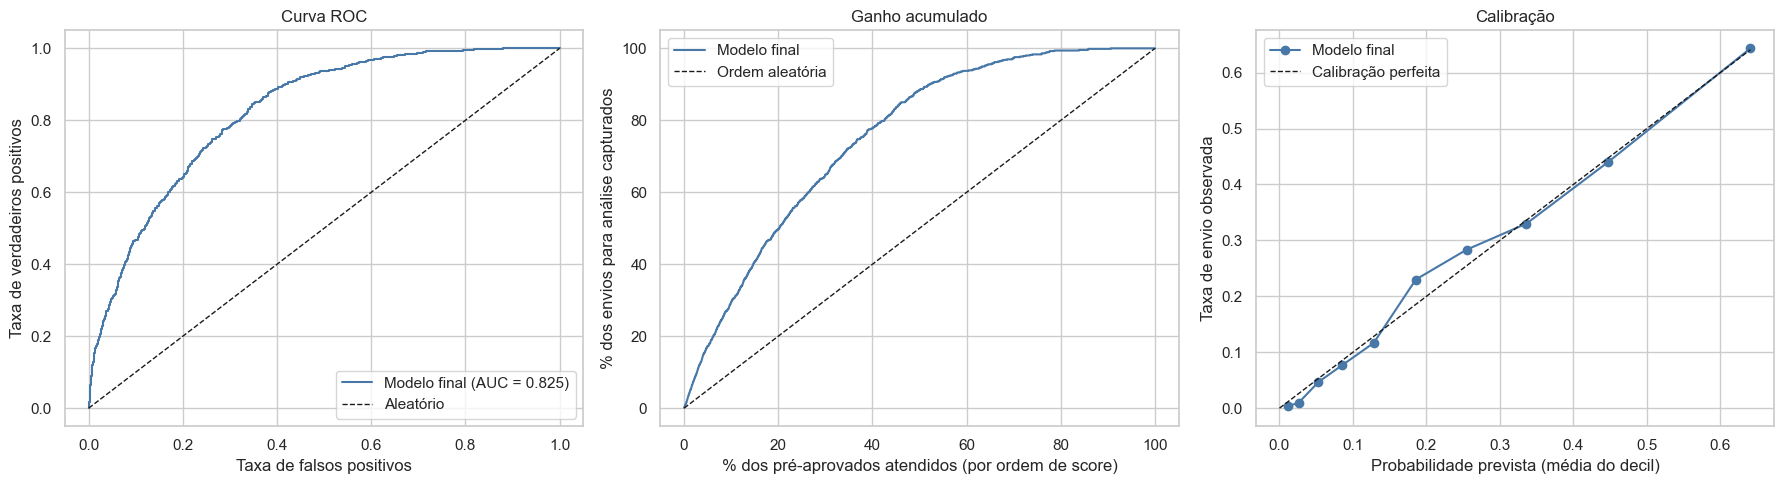

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# curva ROC
fpr, tpr, _ = roc_curve(y_teste, p_teste)
axes[0].plot(fpr, tpr, color='#4878a8', label='Modelo final (AUC = %.3f)' % m_teste['AUC'])
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
axes[0].set(title='Curva ROC', xlabel='Taxa de falsos positivos', ylabel='Taxa de verdadeiros positivos'); axes[0].legend()

# ganho acumulado
ordem = np.argsort(-p_teste)
frac = np.arange(1, len(y_teste) + 1) / len(y_teste)
axes[1].plot(frac * 100, np.cumsum(y_teste[ordem]) / y_teste.sum() * 100, color='#4878a8', label='Modelo final')
axes[1].plot([0, 100], [0, 100], 'k--', lw=1, label='Ordem aleatória')
axes[1].set(title='Ganho acumulado', xlabel='% dos pré-aprovados atendidos (por ordem de score)', ylabel='% dos envios para análise capturados')
axes[1].legend()

# calibração
obs, prev_media = calibration_curve(y_teste, p_teste, n_bins=10, strategy='quantile')
axes[2].plot(prev_media, obs, marker='o', color='#4878a8', label='Modelo final')
axes[2].plot([0, prev_media.max()], [0, prev_media.max()], 'k--', lw=1, label='Calibração perfeita')
axes[2].set(title='Calibração', xlabel='Probabilidade prevista (média do decil)', ylabel='Taxa de envio observada'); axes[2].legend()
plt.tight_layout()

A tabela por decil de score é a leitura operacional do modelo: cada linha é um décimo dos pré-aprovados do teste, do maior para o menor score.

In [19]:
aval = pd.DataFrame({'score': p_teste, 'enviado': y_teste})
aval['decil'] = 10 - pd.qcut(aval.score.rank(method='first'), 10, labels=False)
decis = aval.groupby('decil').agg(clientes=('enviado', 'size'), score_medio=('score', 'mean'),
                                  taxa_envio=('enviado', 'mean'), enviados=('enviado', 'sum'))
decis['lift'] = decis.taxa_envio / y_teste.mean()
decis['captura_acumulada'] = decis.enviados.cumsum() / y_teste.sum()
decis.round(3)

,clientes,score_medio,taxa_envio,enviados,lift,captura_acumulada
decil,,,,,,
1,300,0.641,0.643,193,2.951,0.295
2,300,0.447,0.440,132,2.018,0.497
3,300,0.336,0.330,99,1.514,0.648
4,300,0.255,0.283,85,1.300,0.778
5,300,0.186,0.230,69,1.055,0.884
6,300,0.128,0.117,35,0.535,0.937
7,300,0.085,0.077,23,0.352,0.972
8,300,0.053,0.047,14,0.214,0.994
9,300,0.026,0.010,3,0.046,0.998


# 7. Robustez <a id="7"></a>

### 7.1 Validação fora do tempo

O `id` é sequencial e serve como aproximação da ordem de chegada dos leads. A taxa de envio para análise muda ao longo do tempo, o que indica mudança de operação ou de mix de leads. Para simular o uso real, o modelo é treinado nos 80% de ids mais antigos e avaliado nos 20% mais recentes.

In [20]:
ordenado = dados.sort_values('id').reset_index(drop=True)
print('Taxa de envio por quintil de id (do mais antigo ao mais recente):',
      (ordenado.groupby(pd.qcut(ordenado.id, 5, labels=False))[ALVO].mean() * 100).round(1).tolist())

corte = int(len(ordenado) * 0.8)
antigo, recente = ordenado.iloc[:corte], ordenado.iloc[corte:]
Xa, Xr = criar_variaveis(antigo), criar_variaveis(recente)
ya, yr = antigo[ALVO].astype(int).values, recente[ALVO].astype(int).values
p_oot = prever(ajustar_lgb(preparar(Xa, V_FINAL, Xa), ya, SEMENTES), preparar(Xr, V_FINAL, Xa))
pd.DataFrame({'Teste aleatório': m_teste, 'Fora do tempo (20% mais recentes)': metricas(yr, p_oot)}).T.round(3)

Taxa de envio por quintil de id (do mais antigo ao mais recente): [11.8, 20.9, 28.1, 26.4, 21.8]


,AUC,PR-AUC,KS,Lift top 10%,Captura top 20%,Brier
Teste aleatório,0.825,0.557,0.497,2.951,0.497,0.130
Fora do tempo (20% mais recentes),0.785,0.476,0.439,2.477,0.457,0.142


### 7.2 Sensibilidade a `form_completed`

Se a ficha cadastral só estiver disponível depois do primeiro contato, ela não pode ser usada na priorização. O modelo abaixo é treinado sem essa variável.

In [21]:
V_SEM_FICHA = [v for v in V_FINAL if v != 'form_completed']
p_sem_ficha = prever(ajustar_lgb(preparar(X_treino, V_SEM_FICHA, X_treino), y_treino, SEMENTES), preparar(X_teste, V_SEM_FICHA, X_treino))
pd.DataFrame({'Modelo final': m_teste, 'Sem form_completed': metricas(y_teste, p_sem_ficha)}).T.round(3)

,AUC,PR-AUC,KS,Lift top 10%,Captura top 20%,Brier
Modelo final,0.825,0.557,0.497,2.951,0.497,0.130
Sem form_completed,0.799,0.493,0.459,2.752,0.462,0.138


# 8. Interpretação do modelo <a id="8"></a>

### 8.1 Importância por permutação

Cada variável é embaralhada na base de teste (5 repetições) e mede-se a queda na AUC. Quanto maior a queda, mais o modelo depende da variável. Os nomes vêm diretamente das colunas do DataFrame usado no treino.

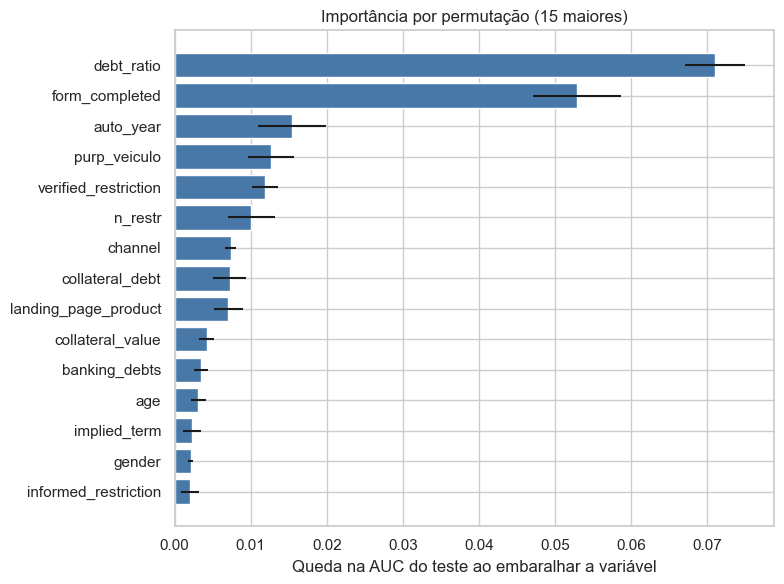

,queda_auc,desvio
debt_ratio,0.0710,0.0040
form_completed,0.0529,0.0057
auto_year,0.0154,0.0045
purp_veiculo,0.0127,0.0030
verified_restriction,0.0119,0.0017
n_restr,0.0101,0.0030
channel,0.0074,0.0007
collateral_debt,0.0072,0.0022
landing_page_product,0.0071,0.0019
collateral_value,0.0042,0.0010


In [22]:
rng = np.random.default_rng(SEED)
quedas = {}
for col in V_FINAL:
    q = []
    for _ in range(5):
        Xperm = Xp_teste.copy()
        Xperm[col] = Xperm[col].values[rng.permutation(len(Xperm))]
        q.append(m_teste['AUC'] - roc_auc_score(y_teste, prever(modelo_final, Xperm)))
    quedas[col] = (np.mean(q), np.std(q))
imp = pd.DataFrame(quedas, index=['queda_auc', 'desvio']).T.sort_values('queda_auc', ascending=False)

top = imp.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top.index, top.queda_auc, xerr=top.desvio, color='#4878a8')
plt.xlabel('Queda na AUC do teste ao embaralhar a variável'); plt.title('Importância por permutação (15 maiores)')
plt.tight_layout(); plt.show()
imp.head(10).round(4)

### 8.2 Valores SHAP

Os valores SHAP mostram a direção do efeito: cada ponto é um cliente do teste, a posição horizontal é o quanto a variável empurrou o score para cima ou para baixo e a cor é o valor da variável (para as categóricas a cor não tem interpretação ordinal).

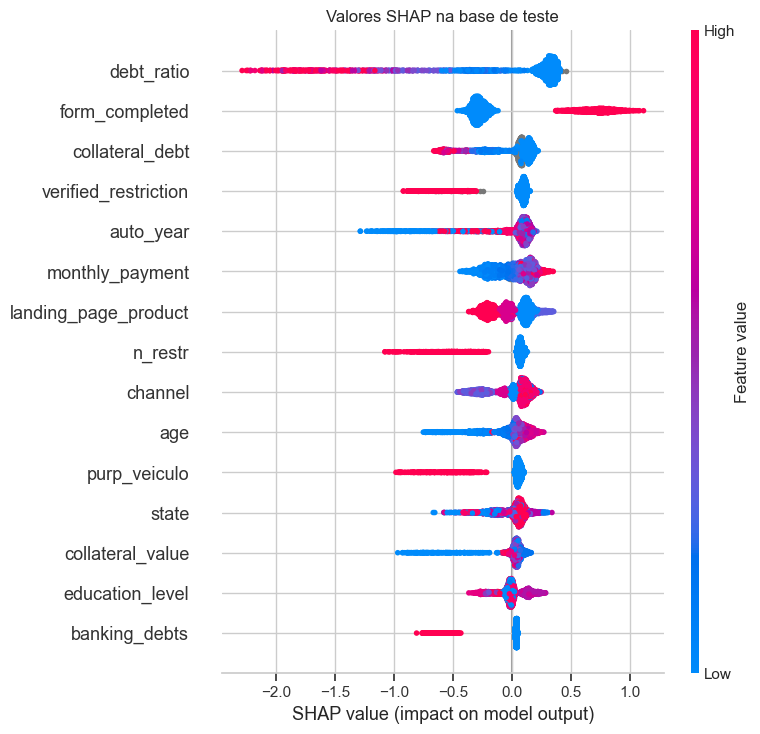

In [23]:
contrib = np.mean([m.booster_.predict(Xp_teste, pred_contrib=True)[:, :-1] for m in modelo_final], axis=0)
X_cores = Xp_teste.copy()
for col in CATEGORICAS:
    X_cores[col] = X_cores[col].cat.codes.replace(-1, np.nan)
shap.summary_plot(contrib, X_cores.astype(float), max_display=15, show=False)
plt.title('Valores SHAP na base de teste'); plt.tight_layout()

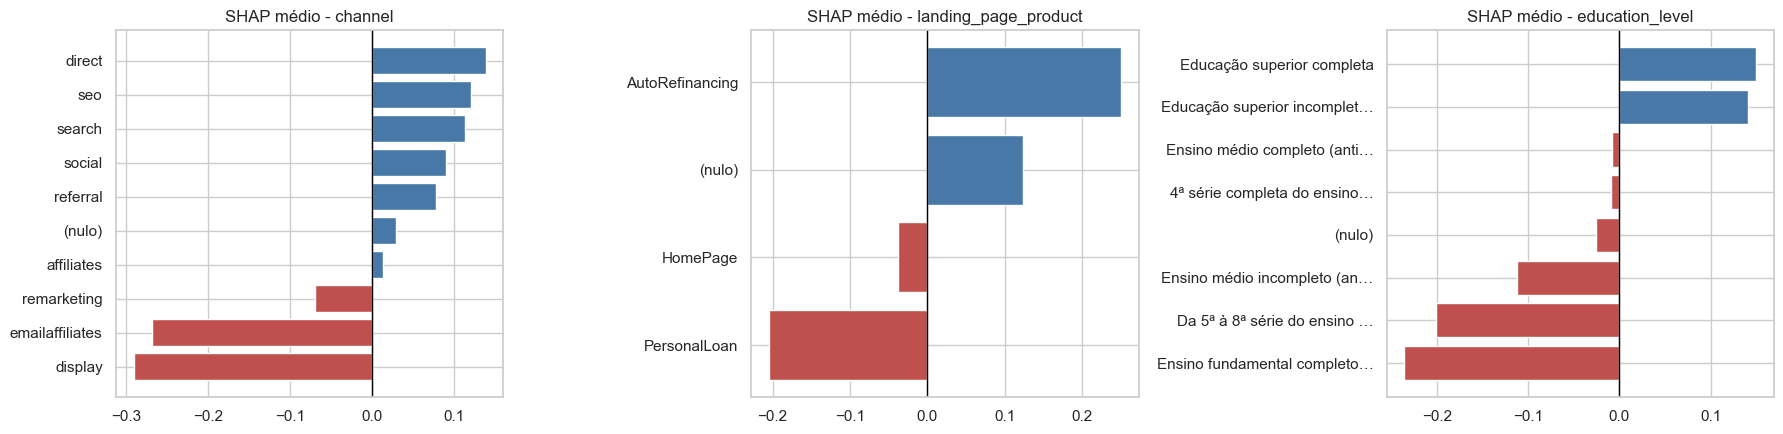

In [24]:
# efeito médio de algumas variáveis sobre o score (em log-odds), para leitura direta
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for col, ax in zip(['channel', 'landing_page_product', 'education_level'], axes):
    efeito = pd.Series(contrib[:, V_FINAL.index(col)]).groupby(X_teste[col].values).agg(['mean', 'size'])
    efeito = efeito[efeito['size'] >= 30].sort_values('mean')
    rotulos = [r if len(r) <= 28 else r[:27] + '…' for r in efeito.index]
    ax.barh(rotulos, efeito['mean'], color=np.where(efeito['mean'] > 0, '#4878a8', '#c0504d'))
    ax.axvline(0, color='black', lw=1); ax.set_title('SHAP médio - ' + col)
plt.tight_layout()

Leitura dos resultados:

* **Dívida do veículo** (`debt_ratio`, `collateral_debt`): é o fator mais importante. Quanto maior a dívida em relação ao valor do carro, menor a chance de envio, o que é coerente com o produto, já que um carro muito financiado serve pouco como garantia.
* **Ficha completa** (`form_completed`): quem completou a ficha tem score bem mais alto. É o sinal de engajamento mais forte.
* **Restrições** (`verified_restriction`, `n_restr`, `banking_debts`): mesmo entre pré-aprovados, ter restrição reduz bastante a chance de envio.
* **Carro** (`auto_year`, `collateral_value`): carros muito antigos ou de valor baixo reduzem o score.
* **Origem do lead** (`channel`, `landing_page_product`): leads de canais diretos, SEO e busca, e os que entraram pela página de refinanciamento de veículo, convertem mais; display, e-mail de afiliados e a página de empréstimo pessoal convertem menos.
* **Motivo do empréstimo** (`purp_veiculo`): citar carro ou moto no motivo reduz o score, possivelmente porque o cliente quer comprar ou quitar um veículo e não usar o atual como garantia.

# 9. Conclusão <a id="9"></a>

Foi desenvolvido um modelo que estima a probabilidade de um cliente pré-aprovado ser enviado para análise de crédito.

**Desempenho na base de teste (3.000 pré-aprovados que não participaram de nenhuma decisão):**

| Métrica | Modelo final | Sem modelo |
|---|---|---|
| AUC-ROC | 0,825 (IC 95%: 0,809 a 0,841) | 0,500 |
| PR-AUC | 0,557 | 0,218 |
| KS | 0,497 | 0 |
| Brier | 0,130 | 0,170 |

A versão anterior do notebook reportava AUC de 0,782, em uma amostra reduzida pelo descarte indevido de linhas. No mesmo protocolo e na mesma base de teste desta versão, um LightGBM apenas com as variáveis antigas atinge 0,806; as novas variáveis levam a 0,825.

**Uso para priorização do atendimento:**

* Os 10% de maior score têm taxa de envio de 64%, contra 22% na média (lift de 2,95).
* Atendendo os 20% de maior score capturam-se 50% de todos os envios para análise; com 50% dos leads, 88%.
* Os 30% de menor score concentram menos de 3% dos envios e podem ir para o fim da fila ou para um fluxo automatizado.
* As probabilidades estão bem calibradas (o score médio de cada decil acompanha a taxa observada), então podem ser usadas diretamente para estimar o volume esperado de envios de uma fila.

**Limitações e próximos passos:**

* **Mudança ao longo do tempo.** Treinando nos leads mais antigos e avaliando nos 20% mais recentes a AUC cai para 0,785. A taxa de envio variou de 12% a 28% no período, portanto o modelo deve ser monitorado e retreinado periodicamente, e a estimativa mais realista de desempenho em produção está entre 0,78 e 0,82.
* **`form_completed`.** Se essa informação não existir no momento da priorização, o modelo sem ela atinge AUC de 0,799.
* **Ganho sobre um modelo linear.** A regressão logística com as mesmas variáveis chega a 0,819 no teste. A maior parte do ganho vem das variáveis, não do algoritmo; se interpretabilidade ou simplicidade de implantação pesarem, o modelo linear é uma alternativa viável.
* **Alvo.** O envio para análise depende também da capacidade e das decisões do time de atendimento, não só do cliente. Um teste A/B comparando a fila ordenada pelo score com a fila atual é o passo seguinte para medir o ganho real.
* **Dados adicionais.** Data e hora do lead, histórico de contatos e o prazo do empréstimo (hoje vazio) devem trazer ganho adicional.